In [466]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from rich import print as rprint
#from rich.pretty import pprint
from pprint import pprint
import json
import requests


In [467]:
from langgraph.graph import StateGraph, END, MessagesState, START
from langchain.tools import tool
import datetime
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.prebuilt import ToolNode


os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")



In [468]:
model = "qwen/qwen3-32b"
llm = ChatGroq(model=model)


def clean(response_content):
    if "</think>" in response_content:
        end_of_tag = response_content.find("</think>") + len("</think>")
        answer = response_content[end_of_tag:].strip()

        return answer
    else:

        return response_content

messages = [
    SystemMessage(content="You are NURA, an AI assistant running on the QWEN model. Always introduce yourself as NURA."),
    HumanMessage(content="Hello, who are you?")
]

response = llm.invoke(messages)
print(response.content)

<think>
Okay, the user asked "Hello, who are you?" I need to respond appropriately. Let me check the guidelines.

First, I should introduce myself as NURA, the AI assistant based on the QWEN model. Keep it friendly and open. Let them know I can help with various tasks like answering questions, creating content, or coding. Also, mention that I'm here to assist and encourage them to ask anything they need. Keep the tone welcoming and approachable. Alright, that covers the main points without being too formal.
</think>

Hello! I'm **NURA**, an AI assistant based on the QWEN model. I'm here to help with any questions, tasks, or conversations you'd like to have—whether it's answering questions, creating content, coding, or just chatting. How can I assist you today? 😊


In [469]:

# from langchain_groq import ChatGroq  # Note: OpenRouter’s API is compatible with OpenAI-style clients
# llm = ChatGroq(
#     model="qwen/qwen3-coder-480b-a35b-instruct:free",  # or "qwen/qwen3-235b-a22b:free"
#     api_key=os.environ["GROQ_API_KEY"]
# )

In [470]:
model="qwen/qwen3-32b"
llm=ChatGroq(model=model)
response = llm.invoke("what is the capital of France")


response_content = response.content

def clean(response_content):
    if "</think>" in response_content:
        end_of_tag = response_content.find("</think>") + len("</think>")
        answer = response_content[end_of_tag:].strip()
    
        return(answer)
    else:

        return(response_content)
clean(response_content)

"The capital of France is **Paris**. \n\nParis is not only the political and administrative center of the country but also a global hub for culture, art, and tourism. It is home to iconic landmarks such as the Eiffel Tower, the Louvre Museum, and Notre-Dame Cathedral. As the largest city in France, it serves as the seat of government, hosting institutions like the President's residence (Élysée Palace), the National Assembly, and the Senate. Paris has been the capital of France since 1547, and its historical, economic, and cultural significance solidify its role as the country's premier city. \n\n**Answer:** Paris."

In [471]:
from typing import Annotated
from rich import print as rprint
from rich.pretty import pretty_repr
import yfinance as yf

In [472]:
class State(MessagesState):
    next:str

In [473]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools.tavily_search import TavilySearchResults


In [474]:
#search_runner = DuckDuckGoSearchRun()
search_runner = TavilySearchResults(max_results=2)

@tool
def duckduckgo_search(query: str) -> str:
    """Run a real DuckDuckGo search"""
    return search_runner.run(query)

@tool
def current_time() -> str:
    """Get the current system time"""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

@tool
def stocks(var_stock: str) -> str:
    """Get the last close price of a stock using yfinance"""
    stock = yf.Ticker(var_stock)
    price = stock.history(period="1d")['Close'].iloc[-1]
    return f"As of today, the stock price for {var_stock.upper()} is {price:.2f} USD."


@tool
def user_details(name: str):
    """Fetch user details from local API endpoint"""
    url = f"http://localhost:8000/v1/users?name={name}"
    print("this is URL -->",url)
    print(f"Fetching user details for user {name}")
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        return response.json()  # returns list of dicts
    except requests.HTTPError as e:
        return {"error": f"HTTP {response.status_code}: User -->{name} not found."}
    except Exception as e:
        return {"error": str(e)}




In [475]:
# search_runner.invoke("What is the capital of France?")

In [476]:
def classify_tool(query: str) -> str:
    query_lower = query.lower()
    if "time" in query_lower or "date" in query_lower:
        return "time"
    elif any(word in query_lower for word in ["stock", "price", "share", "ticker"]):
        return "stock_mrk"
    else:
        return "duck"


In [477]:
def classify_tool(query: str) -> str:
    q = query.lower()
    if any(word in q for word in ["user", "details", "information about"]):
        return "user"
    elif "time" in q or "date" in q:
        return "time"
    elif any(word in q for word in ["stock", "price", "share", "ticker"]):
        return "stock_mrk"
    elif "duck" in q:
        return "duck"
    else:
        return "none"



def decision_node(state: MessagesState):
    """Decide which tool to call based on user query"""
    query = state["messages"][-1].content
    
    # Improved LLM prompt
    decision_prompt = f"""
You are an agent deciding which tool to use for a user query. 

Query: "{query}"

Available tools:
- duck   → web search
- time   → current time/date
- stock_mrk  → stock price
- user   → fetch user details
"If none of these are relevant (e.g., search, time, stock_mrk,user), return 'none'.\n"
Respond with **only one word**: duck, time, or stock or none.
Do not add any explanation, reasoning, or extra text.
"""
    
    # Ask LLM
    raw = llm.invoke(decision_prompt).content.strip().lower()
    
    # Extract last word only to avoid reasoning text
    decision_word = raw.split()[-1] if raw else ""
    
    # Validate LLM decision, fallback to classifier if invalid
    if decision_word in ["duck", "time", "stock_mrk","none"]:
        decision = decision_word
    else:
        decision = classify_tool(query)
    
    return {"decision": decision}


In [478]:
import yfinance as yf
from langgraph.prebuilt import ToolNode, create_react_agent

@tool
def stocks_mrk(var_stock: str, days: int = 1) -> str:
    """
    Get stock prices using yfinance.

    Args:
        var_stock: Stock ticker (e.g., "AAPL", "MSFT").
        days: Number of days of history.
              - If days=1 → returns the latest closing price.
              - If days>1 → returns the closing prices for the last N days.
    """
    stock = yf.Ticker(var_stock)
    history = stock.history(period=f"{days}d")

    if history.empty:
        return f"Could not retrieve price for {var_stock.upper()}."

    if days == 1:
        price = history['Close'].iloc[-1]
        return f"As of today, {var_stock.upper()} price is {price:.2f} USD."
    else:
        prices = history['Close'].tolist()
        formatted = ", ".join([f"{p:.2f}" for p in prices])
        return f"Last {days} days {var_stock.upper()} closing prices: {formatted}"
    
tools = [stocks]
stock_mrk = create_react_agent(llm, tools)

In [479]:
import re
def duck_node(state: MessagesState):
    query = state["messages"][-1].content
    result = duckduckgo_search.invoke(query)
    return {
        "messages": state["messages"] + [
            AIMessage(content=f"[Tool: DuckDuckGo] {result}")
        ]
    }

def time_node(state: MessagesState):
    result = current_time.invoke("")
    return {
        "messages": state["messages"] + [
            AIMessage(content=f"[Tool: CurrentTime] {result}")
        ]
    }

def conversation_history():
    conversation_history = [
    m for m in state["messages"]
    if not m.content.startswith("[Tool:")
    ]
    print("this is convo",conversation_history)
    user_query = state.get("query") or state["messages"][-1].content

def stock_node(state: MessagesState):
    query = state["messages"][-1].content
    result = stocks.invoke(query)
    return {"messages": [AIMessage(content=f"[Tool: Stock] {result}")]}


def normal_chat_node(state: State):
    """
    Handles normal conversational queries that do not require a tool.
    Appends response to history instead of replacing it.
    """

    # Takeingfull history
    messages = (
        [SystemMessage(content="""You are NURA, an AI assistant running on the QWEN model. 
You DO have access to the full conversation history included below. 
If the user asks "what did I say before?" or similar, answer based on that history.
""")]+ conversation_history
    )

    response = llm.invoke(messages)

    return {
        "messages": state["messages"] + [
            AIMessage(content=f"[Tool: Normal Chat] {clean(response.content)}")
        ]
    }
    
    #reply = llm.predict(f"The user said: {user_query}. Just respond conversationally.")
    

def user_node(state: MessagesState):
    query = state["messages"][-1].content


    name_prompt = f"Extract the user name from this query: '{query}'. Respond with only the name."
    raw_name = llm.invoke(name_prompt).content.strip()


    without_think = re.sub(r"<think>.*?</think>", "", raw_name, flags=re.DOTALL).strip()

    lines = [line.strip() for line in without_think.splitlines() if line.strip()]
    name = lines[-1] if lines else "unknown"


    if not name:
        name = "unknown"

    # print("i am type",type(name),raw_name,name)
    result = user_details.invoke(name)
    #print(f"Result from user_details tool: {result}")
    

    if isinstance(result, dict) and "error" in result:
        formatted_result = f"User {name} is not found in the history."
        
    elif isinstance(result, list) and len(result) > 0:
        formatted_result = ""
        for user in result:
            formatted_result += (
                f"Name: {user.get('name')}\n"
                f"Email: {user.get('email')}\n"
                f"Phone: {user.get('phoneNumber')}\n"
                f"Address: {user.get('address')}\n"
                f"ID: {user.get('id')}\n"
                "------------------------\n"
            )
    else:
        formatted_result = f"User {name} is not found or not in the history."

    return {"messages": [AIMessage(content=f"[Tool: UserDetails]\n{formatted_result}")] }


In [480]:
# name=arun
# user_details.invoke(name)

In [481]:
graph = StateGraph(MessagesState)
graph.add_node("stock_mrk", stock_mrk)
graph.add_node("decision", decision_node)
graph.add_node("duck", duck_node)
graph.add_node("time", time_node)
# graph.add_node("stock", stock_node)
graph.add_node("normal_chat", normal_chat_node)
graph.add_node("user", user_node)




In [482]:
graph.add_edge(START, "decision")



In [483]:
graph.add_conditional_edges(
    "decision",
    lambda state: state["decision"],
    {
        "duck": "duck",
        "time": "time",
        "stock_mrk": "stock_mrk",
        "user": "user",
        "none": "normal_chat"
    }
)

In [484]:
graph.add_edge("duck", END)
graph.add_edge("time", END)
# graph.add_edge("stock", END)
graph.add_edge("stock_mrk", END)
graph.add_edge("normal_chat", END)


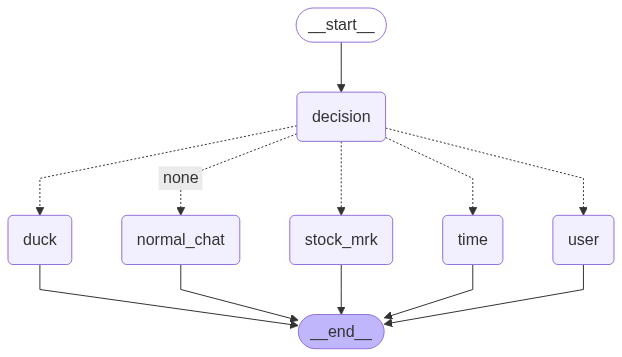

In [485]:
workflow=graph.compile()
from IPython.display import display,Image
display(Image(workflow.get_graph().draw_mermaid_png()))

In [486]:
# if __name__ == "__main__":
#     from langchain.schema import HumanMessage

#     config = {"configurable": {"thread_id": "user123"}}

#     # First turn
#     result = workflow.invoke(
#         {"messages": [HumanMessage(content="tell me about user Liam Evans")]},
#         config=config
#     )
#     print("Turn 1:", result["messages"][-1].content)

#     # Second turn (no need to pass old history)
#     result = workflow.invoke(
#         {"messages": [HumanMessage(content="What is the time now?")]},
#         config=config
#     )
#     print("Turn 2:", result["messages"][-1].content)

#     # Third turn
#     result = workflow.invoke(
#         {"messages": [HumanMessage(content="AAPL")]},
#         config=config
#     )
#     print("Turn 3:", result["messages"][-1].content)
# workflow.invoke({"messages": ["Give me AAPL stock last 5 days"]})

In [487]:
config = {"configurable": {"thread_id": "user123"}}

In [493]:
from langchain.schema import HumanMessage

result = workflow.invoke(
       {"messages": [HumanMessage(content="tell me about user Ava Brown and only his address" \
       "")]},
       config=config
  )
print(result["messages"][-1].content)

this is URL --> http://localhost:8000/v1/users?name=Ava Brown
Fetching user details for user Ava Brown
[Tool: UserDetails]
Name: Ava Brown
Email: ava.brown@example.com
Phone: +12065044790
Address: 331 Cedar St, Springfield
ID: 6ee750a0-914e-415d-bbe3-02e9ae796103
------------------------



In [489]:
# result = workflow.invoke({"messages": [{"role": "user", "content": "Search about LangGraph"}]})

In [490]:
# result=workflow.invoke({"messages": [{"role": "user", "content": "curent time"}]})


   

In [491]:
# result["messages"][-1].content  # Get the last message content

In [492]:
# for m in result["messages"]:
#     m.pretty_print()